# Scikit - Learn

Scikit learn esta basado en el paradigma de la P.O.O y sigue un patron de diseño uniforme basado en estimadores (estimators), predictores (predictors) y transformadores (transformers)

- **Estimador:** Estos objetos se traducen en la clase POO que sirve para entrenar modelos
- **Predictores:** Son objetos que extienden a los estimadores (metodos como ejm. `predict()`, `predict_proba()`)
- **Transformadores:** Se implementa pensando en el preprocesamiento (escalonado, codificado, reduccion de la dimensionalidad)

## Primeros pasos para la construccion de Modelos de Aprendizaje Automatico (Machine Learning)

- Aprendizaje Supervisado

    > $y\sim modelo(x_1, x_2, x_3,...,x_n)$

    > y (Variable Dependiente): Cuantitativa => problemas de regresion

    > y (Variable Dependiente): Cualitativa => problemas de clasificacion

- Aprendizaje No Supervisado

    > No contamos con una variable dependiente

In [1]:
import numpy as np # operaciones de naturaleza matricial
import pandas as pd # manipulacion de datos
import matplotlib.pyplot as plt # visualizacion
import seaborn as sns # visualizacion

In [2]:
# Machine Learning

# funcion para el particonamiento
    # subconjunto de datos para entrenar el modelo => obtener parametros del modelo
    # subconjunto de datos para testear el modelo => obtener indicadores de calidad
from sklearn.model_selection import train_test_split

# modelo de regresion lineal
from sklearn.linear_model import LinearRegression
# submodulo metrics: proveer funciones para calcular indicadores de calidad
from sklearn import metrics

In [3]:
bikes = pd.read_csv('../data/bikes.csv')
bikes

,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82
...,...,...,...,...,...,...,...,...,...,...
726,1,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247
727,1,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644
728,1,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159
729,1,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364


In [4]:
bikes.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    int64  
 1   holiday     731 non-null    int64  
 2   weekday     731 non-null    int64  
 3   workingday  731 non-null    int64  
 4   weathersit  731 non-null    int64  
 5   temp        731 non-null    float64
 6   atemp       731 non-null    float64
 7   hum         731 non-null    float64
 8   windspeed   731 non-null    float64
 9   rentals     731 non-null    int64  
dtypes: float64(4), int64(6)
memory usage: 57.2 KB


### Primer Modelo de Regresion Lineal Multiple

$y = rentals \sim b_0 + b_1 * season + b_2 * holiday + b_3 * weekday + b_4 * workingday + b_5 * weathersit + b_6 * temp + b_7 * atemp + b_8 * hum + b_9 * windspeed + \epsilon$

In [42]:
# Primer paso: particionamiento de los datos

# definir la variable dependiente: columna "rentals"
y = bikes['rentals'] # bikes.rentals
# definir las variables independientes: todas las columnas de bikes excepto rentals
X = bikes.drop(['rentals'], axis=1)
# particionamiento (train_test_split) - utiliza el muestreo aleatorio
X_train, X_test, y_train, y_test =train_test_split(X, y, train_size=0.8)

# Segundo paso:

# instaciar la clase a modelar (LinearRegression)
model_base_bikes = LinearRegression()
# ajustamos el modelo con el subconjutno de entrenamiento
model_base_bikes.fit(X_train, y_train)

# Tercer paso:

# prediccion
y_test_predict = model_base_bikes.predict(X_test)
# indicadores de calidad: MAPE (Error Porcentual Absoluto Medio)
mape = metrics.mean_absolute_percentage_error(y_test, y_test_predict) * 100
mape

79.81045409443902

### Segundo Modelo de Regresion Lienal Multiple

No vamos a considerar las variables que de manera muy natural no son de naturaleza cuantitiva. Consideremos eliminar a las variables:
`season`, `holiday`, `weekday`, `weekday`, `workinday`, `weathersit`

In [11]:
print(bikes.season.unique())
print(bikes.holiday.unique())
print(bikes.weekday.unique())
print(bikes.workingday.unique())
print(bikes.weathersit.unique())

[1 2 3 4]
[0 1]
[6 0 1 2 3 4 5]
[0 1]
[2 1 3]


In [36]:
# Primer paso: particionamiento de los datos

# definir la variable dependiente: columna "rentals"
y = bikes['rentals'] # bikes.rentals
# definir las variables independientes: todas las columnas de bikes excepto rentals
X = bikes.drop(['rentals', 'season', 'holiday', 'weekday', 'workingday', 'weathersit'], axis=1)
# particionamiento (train_test_split) - utiliza el muestreo aleatorio
X_train, X_test, y_train, y_test =train_test_split(X, y, train_size=0.8)

# Segundo paso:

# instaciar la clase a modelar (LinearRegression)
model_base_bikes = LinearRegression()
# ajustamos el modelo con el subconjutno de entrenamiento
model_base_bikes.fit(X_train, y_train)

# Tercer paso:

# prediccion
y_test_predict = model_base_bikes.predict(X_test)
# indicadores de calidad: MAPE (Error Porcentual Absoluto Medio)
mape = metrics.mean_absolute_percentage_error(y_test, y_test_predict) * 100
mape

86.85007387803077

### Analisis de Iteraciones

primer modelo

In [46]:
def analisis_modelo_base(y1, X1):
    # Primer paso: particionamiento de los datos

    # definir la variable dependiente: columna "rentals"
    y = y1 # bikes.rentals
    # definir las variables independientes: todas las columnas de bikes excepto rentals
    X = X1
    # particionamiento (train_test_split) - utiliza el muestreo aleatorio
    X_train, X_test, y_train, y_test =train_test_split(X, y, train_size=0.8)

    # Segundo paso:

    # instaciar la clase a modelar (LinearRegression)
    model_base_bikes = LinearRegression()
    # ajustamos el modelo con el subconjutno de entrenamiento
    model_base_bikes.fit(X_train, y_train)

    # Tercer paso:

    # prediccion
    y_test_predict = model_base_bikes.predict(X_test)
    # indicadores de calidad: MAPE (Error Porcentual Absoluto Medio)
    return metrics.mean_absolute_percentage_error(y_test, y_test_predict) * 100

In [47]:
# realiar 1000 experimentos:

lista_mape_base = list()

for i in range(5000):
    lista_mape_base.append(analisis_modelo_base(y, X))

min(lista_mape_base)

40.94522399496493

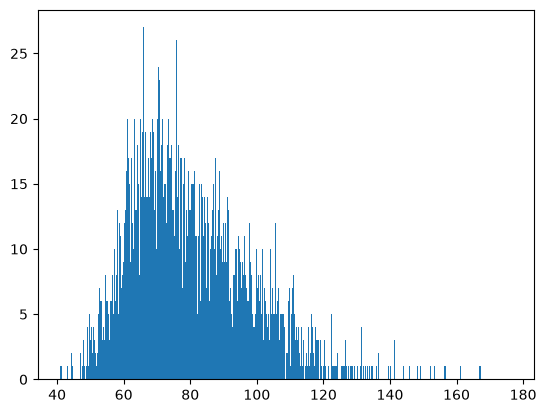

In [48]:
plt.hist(lista_mape_base, bins=1000)
plt.show()

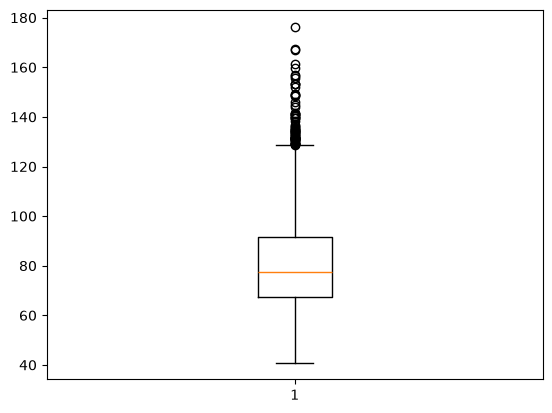

In [49]:
plt.boxplot(lista_mape_base)
plt.show()

### Estrategia de One-Hot-Encoding para las variables de naturalea cualitativa

In [50]:
bikes

,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82
...,...,...,...,...,...,...,...,...,...,...
726,1,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247
727,1,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644
728,1,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159
729,1,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364


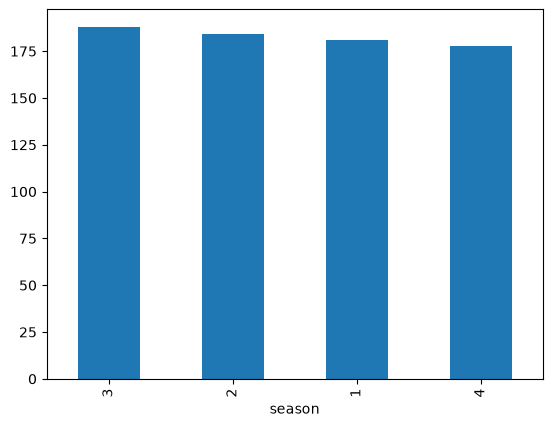

In [51]:
bikes['season'].value_counts().plot(kind='bar')
plt.show()

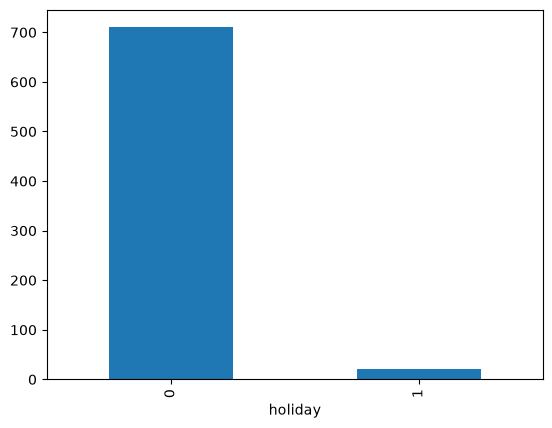

In [52]:
bikes['holiday'].value_counts().plot(kind='bar')
plt.show()

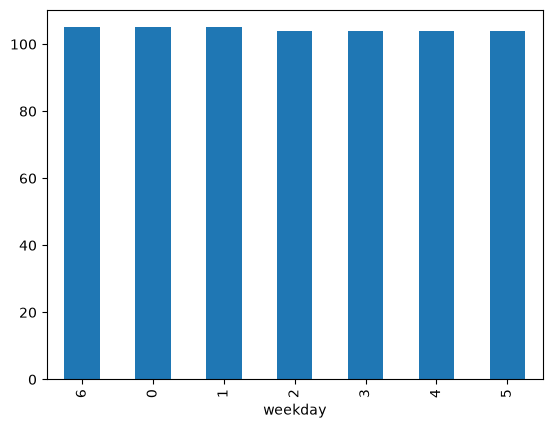

In [53]:
bikes['weekday'].value_counts().plot(kind='bar')
plt.show()

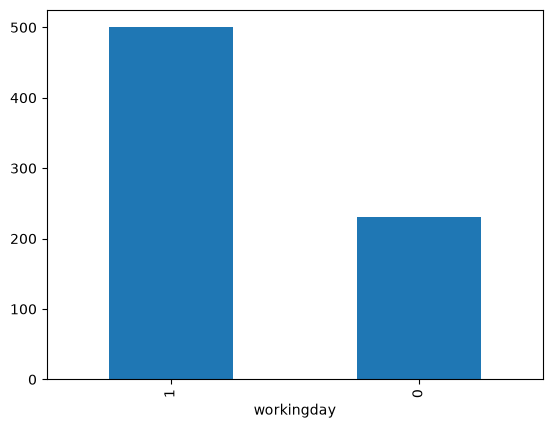

In [54]:
bikes['workingday'].value_counts().plot(kind='bar')
plt.show()

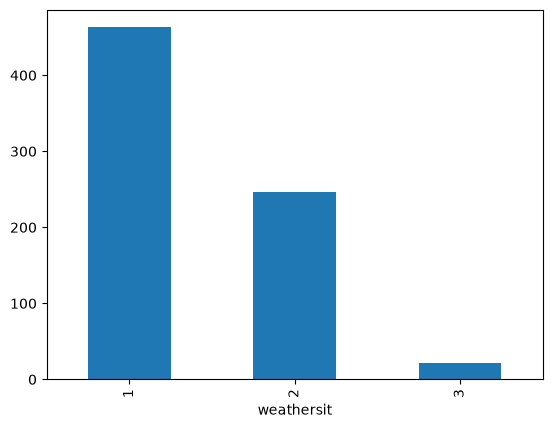

In [55]:
bikes['weathersit'].value_counts().plot(kind='bar')
plt.show()

In [60]:
# construir las columnas One-Hot-Encoding par alas columnas de naturaleza cualitativa
lista_columnas_OHE = ['season', 'holiday', 'weekday', 'workingday', 'weathersit']

data_cualitativa = pd.DataFrame()

for col in lista_columnas_OHE:
    data_cualitativa = pd.concat([data_cualitativa, pd.get_dummies(bikes[col], prefix=col, dtype=int)], axis=1)

data_cualitativa.sample(10)

,season_1,season_2,season_3,season_4,holiday_0,holiday_1,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit_1,weathersit_2,weathersit_3
165,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0
450,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,1,0,0
360,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0
53,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0
4,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0
33,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0
495,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0
540,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0
220,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,1,0,0
123,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0


In [61]:
bikes2 = pd.concat([bikes.drop(lista_columnas_OHE, axis=1), data_cualitativa], axis=1)
bikes2

,temp,atemp,hum,windspeed,rentals,season_1,season_2,season_3,season_4,holiday_0,...,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit_1,weathersit_2,weathersit_3
0,0.344167,0.363625,0.805833,0.160446,331,1,0,0,0,1,...,0,0,0,0,1,1,0,0,1,0
1,0.363478,0.353739,0.696087,0.248539,131,1,0,0,0,1,...,0,0,0,0,0,1,0,0,1,0
2,0.196364,0.189405,0.437273,0.248309,120,1,0,0,0,1,...,0,0,0,0,0,0,1,1,0,0
3,0.200000,0.212122,0.590435,0.160296,108,1,0,0,0,1,...,1,0,0,0,0,0,1,1,0,0
4,0.226957,0.229270,0.436957,0.186900,82,1,0,0,0,1,...,0,1,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,0.254167,0.226642,0.652917,0.350133,247,1,0,0,0,1,...,0,0,1,0,0,0,1,0,1,0
727,0.253333,0.255046,0.590000,0.155471,644,1,0,0,0,1,...,0,0,0,1,0,0,1,0,1,0
728,0.253333,0.242400,0.752917,0.124383,159,1,0,0,0,1,...,0,0,0,0,1,1,0,0,1,0
729,0.255833,0.231700,0.483333,0.350754,364,1,0,0,0,1,...,0,0,0,0,0,1,0,1,0,0


In [64]:
# Primer paso: particionamiento de los datos

# definir la variable dependiente: columna "rentals"
y2 = bikes2['rentals'] # bikes.rentals
# definir las variables independientes: todas las columnas de bikes excepto rentals
X2 = bikes2.drop(['rentals'], axis=1)
# particionamiento (train_test_split) - utiliza el muestreo aleatorio
X_train, X_test, y_train, y_test =train_test_split(X, y, train_size=0.8)

# Segundo paso:

# instaciar la clase a modelar (LinearRegression)
model_base_bikes2 = LinearRegression()
# ajustamos el modelo con el subconjutno de entrenamiento
model_base_bikes2.fit(X_train, y_train)

# Tercer paso:

# prediccion
y_test_predict = model_base_bikes2.predict(X_test)
# indicadores de calidad: MAPE (Error Porcentual Absoluto Medio)
mape = metrics.mean_absolute_percentage_error(y_test, y_test_predict) * 100
mape

81.46332901175501

In [65]:
lista_mape_base = list()

for i in range(1000):
    lista_mape_base.append(analisis_modelo_base(y2, X2))

min(lista_mape_base)

39.43710150742402

In [ ]:
help(LinearRegression)

In [68]:
bikes.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    int64  
 1   holiday     731 non-null    int64  
 2   weekday     731 non-null    int64  
 3   workingday  731 non-null    int64  
 4   weathersit  731 non-null    int64  
 5   temp        731 non-null    float64
 6   atemp       731 non-null    float64
 7   hum         731 non-null    float64
 8   windspeed   731 non-null    float64
 9   rentals     731 non-null    int64  
dtypes: float64(4), int64(6)
memory usage: 57.2 KB


In [69]:
bikes2.describe()

,temp,atemp,hum,windspeed,rentals,season_1,season_2,season_3,season_4,holiday_0,...,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit_1,weathersit_2,weathersit_3
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,...,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,0.495385,0.474354,0.627894,0.190486,848.176471,0.247606,0.251710,0.257182,0.243502,0.971272,...,0.142271,0.142271,0.142271,0.142271,0.143639,0.316005,0.683995,0.633379,0.337893,0.028728
std,0.183051,0.162961,0.142429,0.077498,686.622488,0.431917,0.434293,0.437380,0.429489,0.167155,...,0.349567,0.349567,0.349567,0.349567,0.350963,0.465233,0.465233,0.482212,0.473316,0.167155
min,0.059130,0.079070,0.000000,0.022392,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.337083,0.337842,0.520000,0.134950,315.500000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.498333,0.486733,0.626667,0.180975,713.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,0.655417,0.608602,0.730209,0.233214,1096.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,0.861667,0.840896,0.972500,0.507463,3410.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


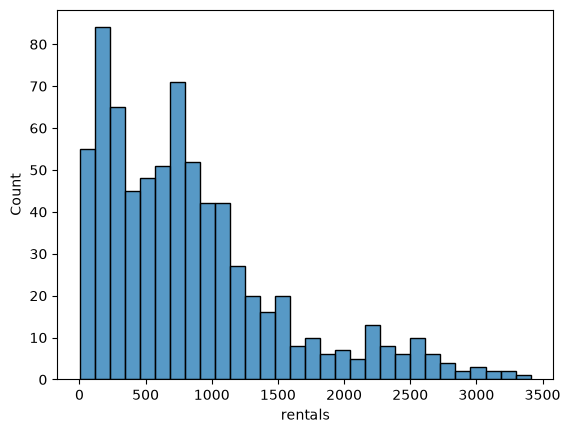

In [71]:
sns.histplot(data=bikes2, x='rentals', bins=30);